In [1]:
import mne
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mne.channels import make_dig_montage
import neurokit2 as nk

In [3]:
data_path = "D:\Developer\EEG_dataset\sub1\sub-001_ses-01_task-GXtESCTT_eeg.set"
raw = mne.io.read_raw_eeglab(data_path, preload=True)

Reading D:\Developer\EEG_dataset\sub1\sub-001_ses-01_task-GXtESCTT_eeg.fdt


C:\Users\Jose\AppData\Local\Temp\ipykernel_16072\1668719478.py:2: RuntimeWarning: Estimated head radius (0.0 cm) is below the 3rd percentile for infant head size. Check if the montage_units argument is correct (the default is "mm", but your channel positions may be in different units).
  raw = mne.io.read_raw_eeglab(data_path, preload=True)


Reading 0 ... 8455575  =      0.000 ...  4227.788 secs...


In [4]:
non_eeg_channels = {
    'BIP1': 'ecg',
    'BIP2': 'eog', 
    'RESP1': 'resp'
}

raw.set_channel_types(non_eeg_channels)

<RawEEGLAB | sub-001_ses-01_task-GXtESCTT_eeg.fdt, 35 x 8455576 (4227.8 s), ~2.21 GiB, data loaded>

In [5]:
raw.set_montage("standard_1005", on_missing='warn')

<RawEEGLAB | sub-001_ses-01_task-GXtESCTT_eeg.fdt, 35 x 8455576 (4227.8 s), ~2.21 GiB, data loaded>

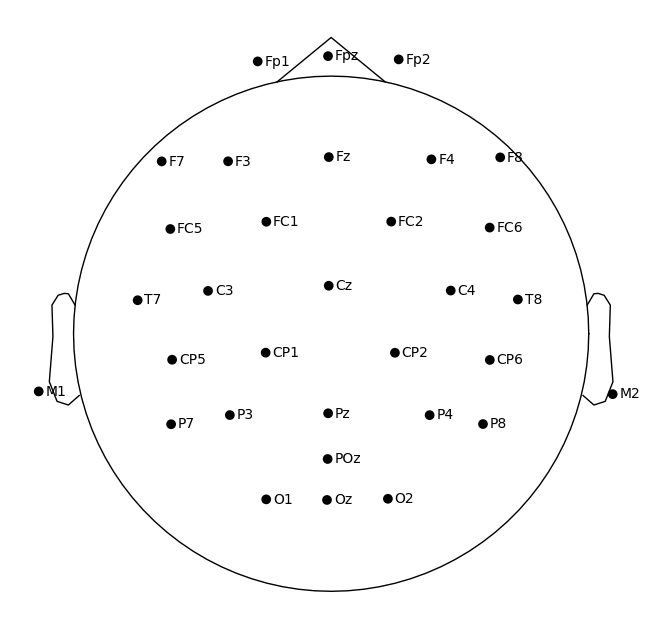

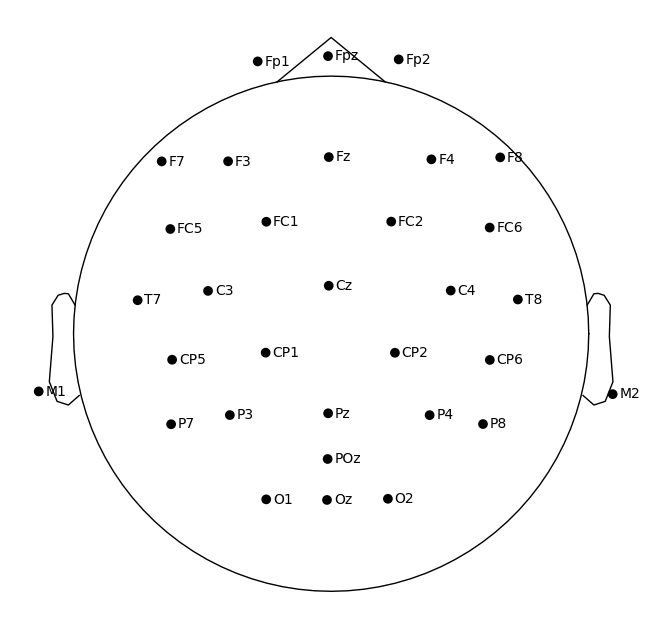

In [6]:
raw.plot_sensors(show_names=True, title="EEG Sensor Positions")

## Events and Stim triggers

In [7]:
events, event_id = mne.events_from_annotations(raw)
event_id

Used Annotations descriptions: [np.str_('0, Impedance'), np.str_('16'), np.str_('2'), np.str_('32')]


{np.str_('0, Impedance'): 1,
 np.str_('16'): 2,
 np.str_('2'): 3,
 np.str_('32'): 4}

In [8]:

events_df = pd.DataFrame(events, columns=['Onset', 'Sample', 'Trigger_Code'])

# Add time in seconds (assuming sample rate is in raw.info['sfreq'])
sfreq = raw.info['sfreq']
events_df['Time_seconds'] = events_df['Onset'] / sfreq

# Map trigger codes to meaningful names (if known)
# Example: event_id contains mapping like { 'stimulus_1': 1, 'response': 2 }
trigger_mapping = {v: k for k, v in event_id.items()}
events_df['Trigger_Name'] = events_df['Trigger_Code'].map(trigger_mapping)

print("Events extracted:")
print(events_df.head(10))
print(f"\nTotal events: {len(events_df)}")
print(f"Unique triggers: {events_df['Trigger_Name'].unique()}")

# Summary of trigger frequencies
trigger_summary = events_df['Trigger_Name'].value_counts()
print("\nTrigger frequency:")
print(trigger_summary)

Events extracted:
     Onset  Sample  Trigger_Code  Time_seconds  Trigger_Name
0        0       0             1        0.0000  0, Impedance
1    40858       0             3       20.4290             2
2  1238885       0             3      619.4425             2
3  1238999       0             2      619.4995            16
4  1309493       0             4      654.7465            32
5  1541032       0             2      770.5160            16
6  1611143       0             4      805.5715            32
7  1843032       0             2      921.5160            16
8  1913304       0             4      956.6520            32
9  2145103       0             2     1072.5515            16

Total events: 26
Unique triggers: [np.str_('0, Impedance') np.str_('2') np.str_('16') np.str_('32')]

Trigger frequency:
Trigger_Name
32              9
16              9
2               6
0, Impedance    2
Name: count, dtype: int64


In [9]:
# Extract sampling frequency
sfreq = raw.info['sfreq']
print(f"Sampling Frequency: {sfreq} Hz")

# Extract channel information
channels_df = pd.DataFrame({
    'Channel_Name': raw.ch_names,
    'Channel_Type': raw.get_channel_types(),
    'Channel_Index': range(len(raw.ch_names))
})

print("\nChannel Information:")
print(channels_df)

# Separate channels by type
eeg_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ == 'eeg']
physio_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ in ['ecg', 'emg', 'eog', 'resp']]
other_channels = [ch for ch, typ in zip(raw.ch_names, raw.get_channel_types()) if typ not in ['eeg', 'ecg', 'emg', 'eog', 'resp']]

print(f"\nEEG Channels: {len(eeg_channels)}")
print(f"Physio Channels: {len(physio_channels)}")
print(f"Other Channels: {len(other_channels)}")

Sampling Frequency: 2000.0 Hz

Channel Information:
   Channel_Name Channel_Type  Channel_Index
0           Fp1          eeg              0
1           Fpz          eeg              1
2           Fp2          eeg              2
3            F7          eeg              3
4            F3          eeg              4
5            Fz          eeg              5
6            F4          eeg              6
7            F8          eeg              7
8           FC5          eeg              8
9           FC1          eeg              9
10          FC2          eeg             10
11          FC6          eeg             11
12           M1          eeg             12
13           T7          eeg             13
14           C3          eeg             14
15           Cz          eeg             15
16           C4          eeg             16
17           T8          eeg             17
18           M2          eeg             18
19          CP5          eeg             19
20          CP1         

In [10]:
physio_channels_list = ['Fp1', 'Fpz', 'Fp2','BIP1']

physio_data = {}
for ch in physio_channels_list:
    ch_data, times = raw[ch, :]
    physio_data[ch] = ch_data.flatten()

# Create DataFrame with time as index
physio_df = pd.DataFrame(physio_data)
physio_df.index = times

# Add time column
physio_df['Time_seconds'] = times

print("\nPhysio DataFrame shape:", physio_df.shape)
print(physio_df.head())


Physio DataFrame shape: (8455576, 5)
             Fp1       Fpz       Fp2      BIP1  Time_seconds
0.0000 -0.021299 -0.020111 -0.024155  0.002692        0.0000
0.0005 -0.021292 -0.020109 -0.024152  0.002698        0.0005
0.0010 -0.021309 -0.020124 -0.024167  0.002701        0.0010
0.0015 -0.021310 -0.020127 -0.024170  0.002719        0.0015
0.0020 -0.021314 -0.020128 -0.024169  0.002731        0.0020


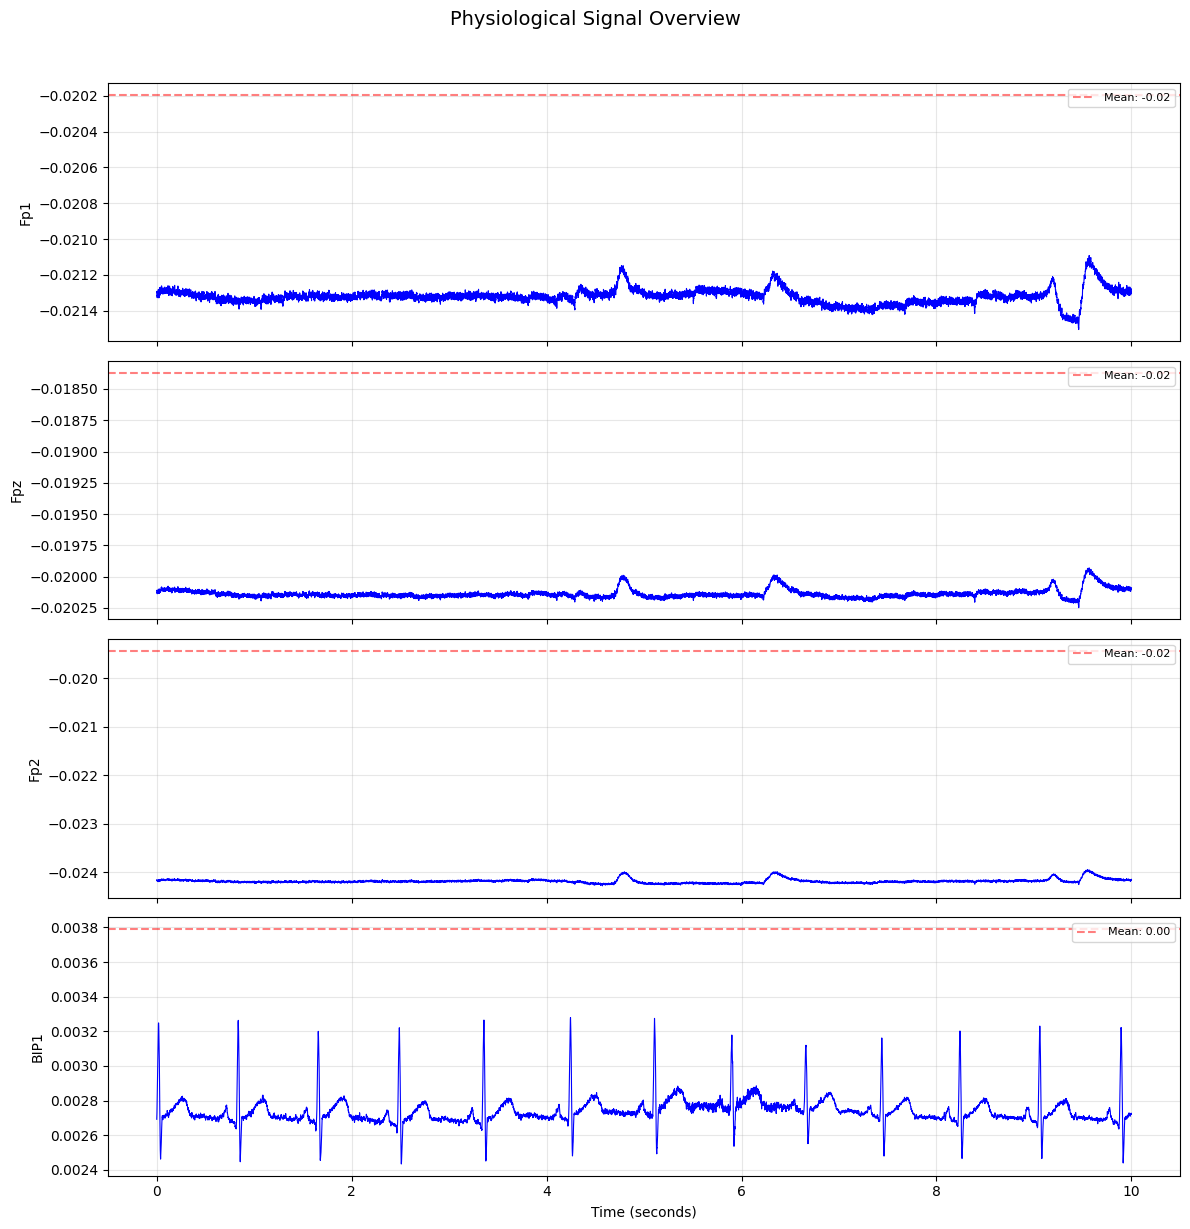

In [ ]:
def plot_physio_channels(physio_df, sfreq, duration=4):
    """Plot first 'duration' seconds of physio data"""
    time_limit = min(duration, len(physio_df) / sfreq)
    mask = physio_df['Time_seconds'] <= time_limit
    
    physio_cols = [col for col in physio_df.columns if col != 'Time_seconds']
    n_channels = len(physio_cols)
    
    if n_channels == 0:
        print("No physiological channels to plot")
        return
    
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3*n_channels), sharex=True)
    if n_channels == 1:
        axes = [axes]
    
    for i, channel in enumerate(physio_cols):
        axes[i].plot(physio_df['Time_seconds'][mask], physio_df[channel][mask], 
                     linewidth=0.8, color='b')
        axes[i].set_ylabel(channel, fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        mean_val = physio_df[channel].mean()
        std_val = physio_df[channel].std()
        axes[i].axhline(mean_val, color='r', linestyle='--', alpha=0.5, 
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend(fontsize=8, loc="upper right")
    
    axes[-1].set_xlabel('Time (seconds)', fontsize=10)
    plt.suptitle('Physiological Signal Overview', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Execute the plots
if len(physio_channels_list) > 0:
    plot_physio_channels(physio_df, sfreq, duration=10)
else:
    print("No physiological channels found to plot")

In [30]:
print("="*60)
print("TRIGGER ANALYSIS")
print("="*60)
# Display trigger information
print("\nTrigger Summary:")
for trigger_name in events_df['Trigger_Name'].unique():
    count = len(events_df[events_df['Trigger_Name'] == trigger_name])
    print(f"  {trigger_name}: {count} events")

CTT_START_TRIGGER = '16' 
CTT_END_TRIGGER = '32' 

def extract_ctt_trials(events_df, start_trigger, end_trigger):
    trials = []
    start_events = events_df[events_df['Trigger_Name'] == start_trigger]
    end_events = events_df[events_df['Trigger_Name'] == end_trigger]
    
    # Pair start and end events in order
    for i, (_, start_row) in enumerate(start_events.iterrows()):
        if i < len(end_events):
            end_row = end_events.iloc[i]
            trials.append({
                'trial_num': i + 1,
                'start_time': start_row['Time_seconds'],
                'end_time': end_row['Time_seconds'],
                'duration': end_row['Time_seconds'] - start_row['Time_seconds']
            })
    return trials

ctt_trials = extract_ctt_trials(events_df, CTT_START_TRIGGER, CTT_END_TRIGGER)

print(f"\nFound {len(ctt_trials)} stimulation trials")
if ctt_trials:
    print(f"Trial durations range: {min(t['duration'] for t in ctt_trials):.2f} - {max(t['duration'] for t in ctt_trials):.2f} seconds")
    print(f"Average trial duration: {np.mean([t['duration'] for t in ctt_trials]):.2f} seconds")

TRIGGER ANALYSIS

Trigger Summary:
  0, Impedance: 2 events
  2: 6 events
  16: 9 events
  32: 9 events

Found 9 stimulation trials
Trial durations range: 0.10 - 35.29 seconds
Average trial duration: 31.22 seconds


In [15]:
physio_df

,Fp1,Fpz,Fp2,BIP1,Time_seconds
0.0000,-0.021299,-0.020111,-0.024155,0.002692,0.0000
0.0005,-0.021292,-0.020109,-0.024152,0.002698,0.0005
0.0010,-0.021309,-0.020124,-0.024167,0.002701,0.0010
0.0015,-0.021310,-0.020127,-0.024170,0.002719,0.0015
0.0020,-0.021314,-0.020128,-0.024169,0.002731,0.0020
...,...,...,...,...,...
4227.7855,-0.017284,-0.016610,-0.014749,0.004166,4227.7855
4227.7860,-0.017286,-0.016607,-0.014749,0.004161,4227.7860
4227.7865,-0.017295,-0.016611,-0.014751,0.004168,4227.7865
4227.7870,-0.017316,-0.016630,-0.014771,0.004206,4227.7870


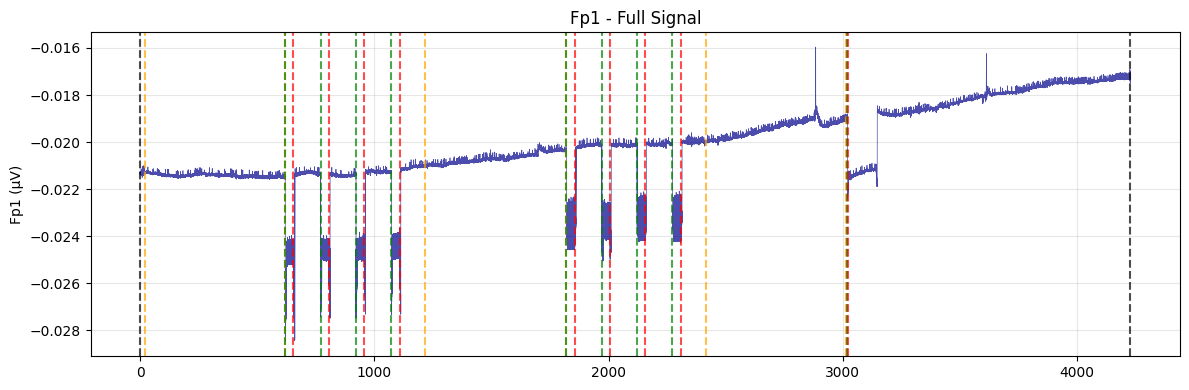

In [16]:
def plot_individual_physio_triggers(physio_df, channel_name):
    """Plot individual physiological channel with statistics"""
    if channel_name not in physio_df.columns:
        print(f"Channel {channel_name} not found")
        return
    
    fig, (ax1) = plt.subplots(1, 1, figsize=(12, 4))
    
    # Full signal
    ax1.plot(physio_df['Time_seconds'], physio_df[channel_name], 
             linewidth=0.5, color='darkblue', alpha=0.7)
    ax1.set_ylabel(f'{channel_name} (µV)', fontsize=10)
    ax1.set_title(f'{channel_name} - Full Signal', fontsize=12)
    ax1.grid(True, alpha=0.3)

    for trial_idx in range(len(events_df)):
        trial = events_df.loc[trial_idx]

        # Mark trial boundaries
        
        match (trial["Trigger_Code"]):
            case 2:
                color="green"
            case 3:
                color="orange"
            case 4:
                color="red"
            case _:
                color="black"

        ax1.axvline(trial['Time_seconds'], color=color, linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Start')
        
    
    plt.tight_layout()
    plt.show()

first_physio = physio_channels_list[0]
plot_individual_physio_triggers(physio_df, first_physio)

## Basic Analysis

In [17]:
ecg_channels = [ch for ch in raw.ch_names if 'BIP1' in ch.upper()]
if ecg_channels:
    ecg_channel = ecg_channels[0]
    print(f"Using ECG channel: {ecg_channel}")
    
    # Extract full ECG data
    ecg_data, times = raw[ecg_channel, :]
    ecg_data = ecg_data.flatten()
    sampling_rate = raw.info['sfreq']
    
    print(f"ECG data shape: {ecg_data.shape}")
    print(f"Sampling rate: {sampling_rate} Hz")

Using ECG channel: BIP1
ECG data shape: (8455576,)
Sampling rate: 2000.0 Hz


### Pre-stim ECG Analysis

In [18]:
def extract_prestim_ecg_epochs(ctt_trials, ecg_data, times, sampling_rate, pre_stim_duration=30):
    """Extract ECG epochs before each trial onset using NeuroKit2"""
    epochs = []
    
    for trial in ctt_trials:
        start_time = trial['start_time']
        epoch_start = max(0, start_time - pre_stim_duration)
        epoch_end = start_time
        
        # Find indices
        start_idx = int(epoch_start * sampling_rate)
        end_idx = int(epoch_end * sampling_rate)
        
        # Extract epoch
        epoch_signal = ecg_data[start_idx:end_idx]
        epoch_times = times[start_idx:end_idx] - start_time  # Center at 0 (trial onset)
        
        epochs.append({
            'trial_num': trial['trial_num'],
            'signal': epoch_signal,
            'times': epoch_times,
            'duration': pre_stim_duration
        })
    
    return epochs

# Extract 1 second before each trial
prestim_epochs = extract_prestim_ecg_epochs(ctt_trials, ecg_data, times, sampling_rate)
print(f"Extracted {len(prestim_epochs)} pre-stimulus epochs")

Extracted 9 pre-stimulus epochs


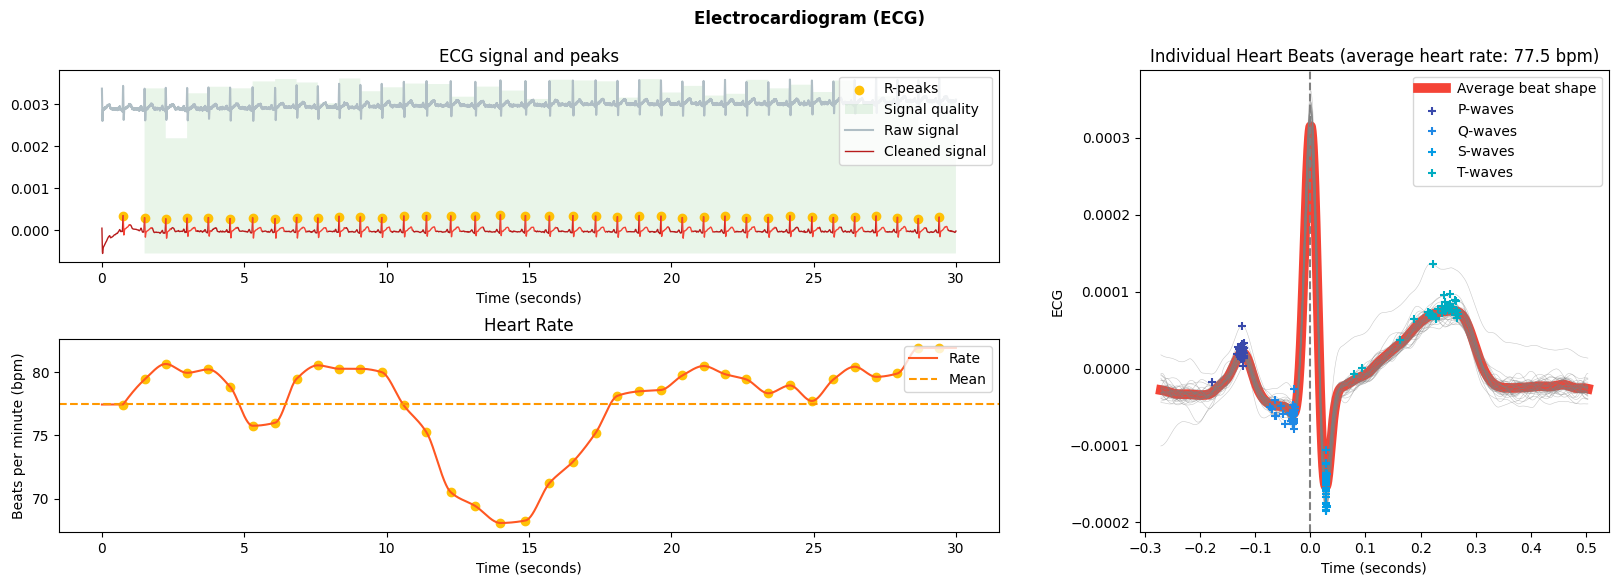

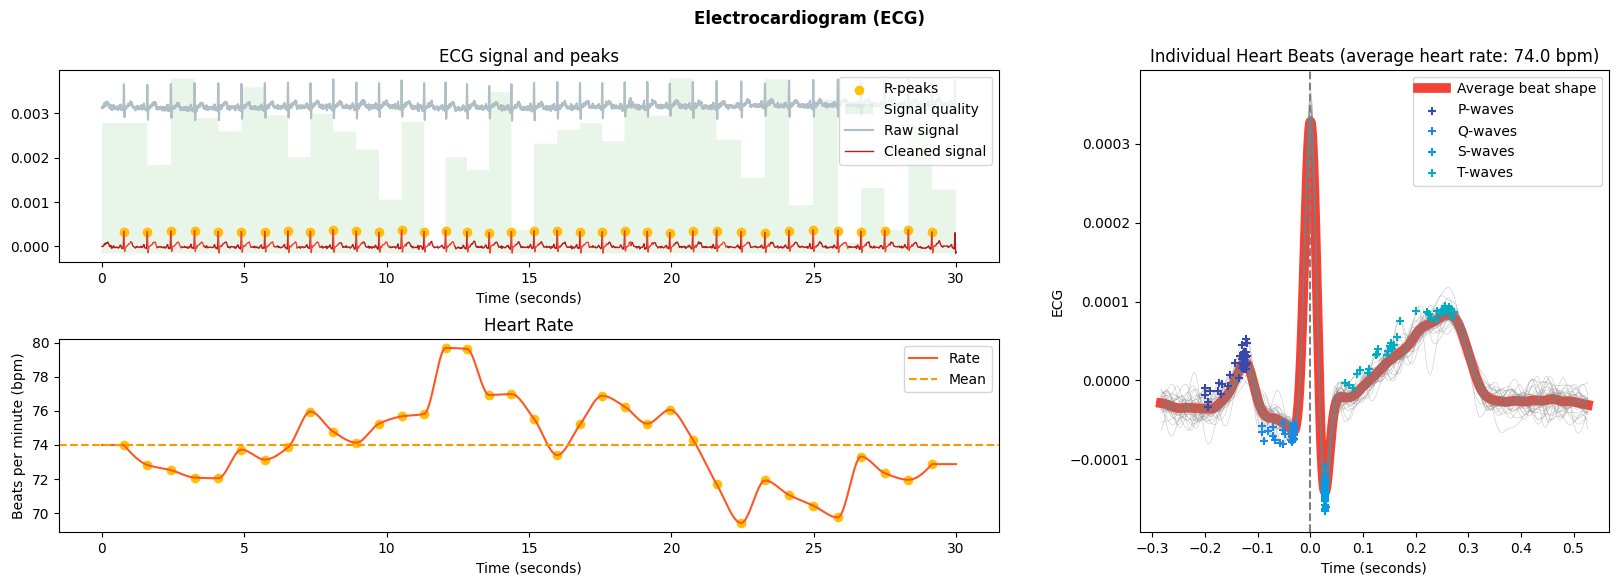

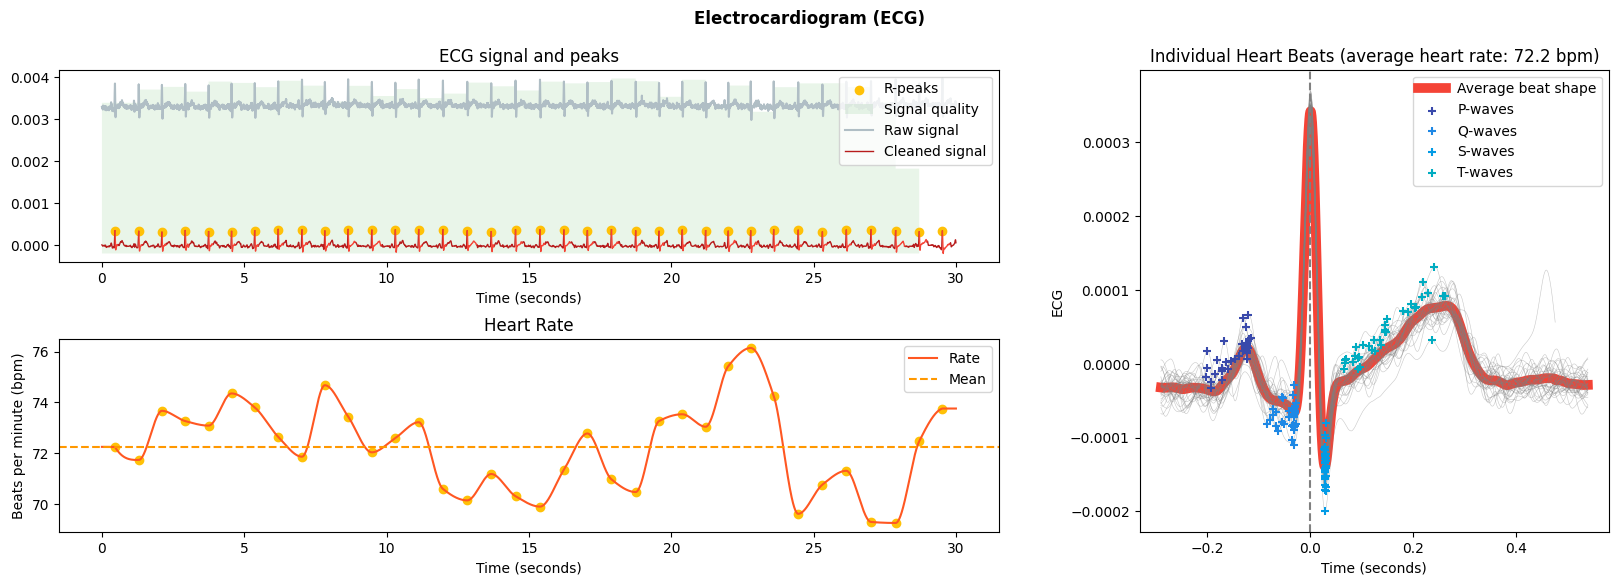

Processed 3 epochs


In [ ]:
def process_ecg_epochs(epochs, sampling_rate):
    """Process each ECG epoch using NeuroKit2"""
    processed_epochs = []
    
    for epoch in epochs:
        # Use NeuroKit2's complete ECG processing pipeline [citation:2][citation:9]
        signals, info = nk.ecg_process(
            epoch['signal'], 
            sampling_rate=sampling_rate
        )
        nk.ecg_plot(signals, info)
        
        fig = plt.gcf()
        fig.set_size_inches(20, 6)
        plt.subplots_adjust(hspace=0.4)
        plt.show()
        
        processed_epochs.append({
            'trial_num': epoch['trial_num'],
            'signals': signals,
            'info': info,
            'times': epoch['times']
        })
    
    return processed_epochs

# Process all pre-stimulus epochs
processed_epochs = process_ecg_epochs(prestim_epochs[:3], sampling_rate)
print(f"Processed {len(processed_epochs)} epochs")

In [20]:
def extract_heartbeat_features(processed_epochs):
    """Extract R-peaks and heart rate features"""
    all_rpeaks = []
    all_heart_rates = []
    
    for epoch in processed_epochs:
        # R-peak locations (in samples) from NeuroKit2 [citation:3][citation:10]
        rpeaks = epoch['info']['ECG_R_Peaks']
        
        # Convert to time (relative to epoch start)
        rpeak_times = rpeaks / sampling_rate
        
        # Calculate instantaneous heart rate
        if len(rpeaks) > 1:
            # RR intervals in milliseconds
            rr_intervals = np.diff(rpeaks) / sampling_rate * 1000
            heart_rate = 60000 / rr_intervals  # bpm
        else:
            heart_rate = []
            rr_intervals = []
        
        all_rpeaks.append({
            'trial_num': epoch['trial_num'],
            'rpeak_indices': rpeaks,
            'rpeak_times': rpeak_times,
            'rr_intervals': rr_intervals,
            'heart_rate': heart_rate
        })
        
        # Calculate mean heart rate for this epoch
        if len(rr_intervals) > 0:
            mean_hr = np.mean(60000 / rr_intervals)
        else:
            mean_hr = np.nan
        all_heart_rates.append(mean_hr)
    
    return all_rpeaks, all_heart_rates

rpeaks_data, heart_rates = extract_heartbeat_features(processed_epochs)

c:\Python310\lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


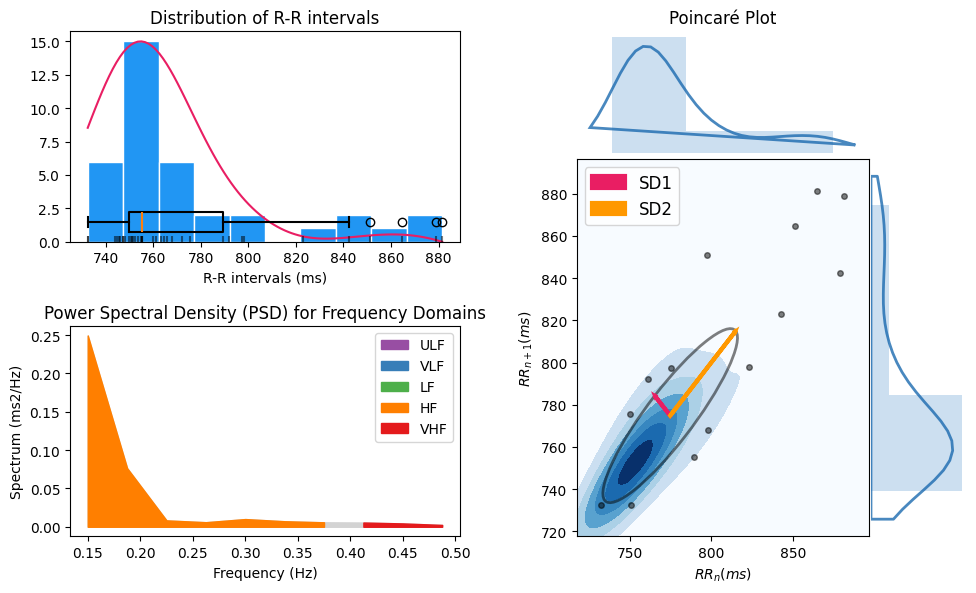


HRV Metrics Summary:


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
Trial_1,774.810811,40.630337,NaN,NaN,NaN,NaN,NaN,NaN,17.969109,18.21248,...,0.449346,0.475734,1.234172,1.399345,1.59106,0.844776,0.314286,0.371429,0.171429,0.142857


In [42]:
def calculate_hrv_metrics(rpeaks_data, sampling_rate):
    """Calculate HRV metrics using NeuroKit2"""
    hrv_metrics = []
    
    for epoch in rpeaks_data:
        if len(epoch['rr_intervals']) >= 2:  # Need at least 2 beats for HRV

            hrv_indices_pre = nk.hrv(epoch['rpeak_indices'], sampling_rate=sampling_rate, show=True)

            fig = plt.gcf()
            fig.set_size_inches(10, 6)
            plt.subplots_adjust(hspace=0.4, wspace=0.3) 
            plt.show()
            
            # Combine all metrics
            trial_metrics = pd.concat([hrv_indices_pre], axis=1)
            trial_metrics.index = [f'Trial_{epoch["trial_num"]}']
            hrv_metrics.append(trial_metrics)
        else:
            print(f"Trial {epoch['trial_num']}: Insufficient beats for HRV ({len(epoch['rr_intervals'])} intervals)")
    
    if hrv_metrics:
        return pd.concat(hrv_metrics)
    else:
        return pd.DataFrame()

# Calculate HRV metrics
hrv_results = calculate_hrv_metrics(rpeaks_data, sampling_rate)
print("\nHRV Metrics Summary:")
hrv_results